In [4]:
%pip install matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os
os.getcwd()

'C:\\Users\\vidya'

In [13]:
df = pd.read_excel(
    r"C:\Users\vidya\Downloads\marketing_campaign_dataset.xlsx",
    engine="openpyxl"
)

In [14]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01 00:00:00,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01 00:00:00,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01 00:00:00,379,4201,3,Health & Wellness


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  str    
 2   Campaign_Type     200005 non-null  str    
 3   Target_Audience   200005 non-null  str    
 4   Duration          200005 non-null  str    
 5   Channel_Used      200005 non-null  str    
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  int64  
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  str    
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  str    
dtypes: float64(2), int64(5), object(1), str(7)
memory usage: 22.9+ MB


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
dtype: int64

In [18]:
df["Channel_Used"].value_counts()

Channel_Used
Email         33599
Google Ads    33440
YouTube       33393
Instagram     33392
Website       33361
Facebook      32820
Name: count, dtype: int64

In [19]:
df.groupby("Channel_Used")["ROI"].mean().sort_values(ascending=False)

Channel_Used
Facebook      5.018672
Website       5.014114
Google Ads    5.003126
Email         4.996487
YouTube       4.993720
Instagram     4.988706
Name: ROI, dtype: float64

In [20]:
df.groupby("Channel_Used")["Conversion_Rate"].mean().sort_values(ascending=False)

Channel_Used
Email         0.080282
Website       0.080182
Google Ads    0.080181
Facebook      0.079990
YouTube       0.079890
Instagram     0.079886
Name: Conversion_Rate, dtype: float64

In [21]:
df.groupby("Channel_Used")["Acquisition_Cost"].mean().sort_values()

Channel_Used
YouTube       12481.570688
Website       12487.842001
Instagram     12491.760002
Facebook      12510.768617
Email         12526.387809
Google Ads    12528.245036
Name: Acquisition_Cost, dtype: float64

In [22]:
df["CTR"] = (df["Clicks"] / df["Impressions"]) * 100

In [23]:
df.groupby("Channel_Used")["CTR"].mean().sort_values(ascending=False)

Channel_Used
YouTube       14.119755
Website       14.096941
Email         14.054269
Facebook      14.049724
Instagram     14.003691
Google Ads    13.918943
Name: CTR, dtype: float64

In [24]:
df["Campaign_Type"].value_counts()

Campaign_Type
Influencer      40170
Search          40157
Display         39988
Email           39871
Social Media    39819
Name: count, dtype: int64

In [25]:
df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=False)

Campaign_Type
Influencer      5.011040
Search          5.008357
Display         5.006497
Email           4.994274
Social Media    4.991781
Name: ROI, dtype: float64

In [26]:
df.groupby("Campaign_Type")["Conversion_Rate"].mean().sort_values(ascending=False)

Campaign_Type
Influencer      0.080315
Social Media    0.080132
Display         0.080088
Search          0.080021
Email           0.079787
Name: Conversion_Rate, dtype: float64

In [27]:
df.groupby("Location")["ROI"].mean().sort_values(ascending=False)

Location
Miami          5.012282
Los Angeles    5.010876
Houston        5.007174
Chicago        5.001555
New York       4.980185
Name: ROI, dtype: float64

In [28]:
df["Customer_Segment"].value_counts()

Customer_Segment
Foodies                40210
Tech Enthusiasts       40154
Outdoor Adventurers    40011
Health & Wellness      39888
Fashionistas           39742
Name: count, dtype: int64

In [29]:
total_impressions = df["Impressions"].sum()
total_clicks = df["Clicks"].sum()
total_conversions = (df["Clicks"] * df["Conversion_Rate"]).sum()

print("Total Impressions:", total_impressions)
print("Total Clicks:", total_clicks)
print("Estimated Conversions:", round(total_conversions))

Total Impressions: 1101488958
Total Clicks: 109957667
Estimated Conversions: 8804734


In [30]:
overall_ctr = (total_clicks / total_impressions) * 100
print("Overall CTR:", round(overall_ctr, 2), "%")

Overall CTR: 9.98 %


In [31]:
df.groupby("Channel_Used")["Conversion_Rate"].mean().sort_values(ascending=False)

Channel_Used
Email         0.080282
Website       0.080182
Google Ads    0.080181
Facebook      0.079990
YouTube       0.079890
Instagram     0.079886
Name: Conversion_Rate, dtype: float64

In [32]:
channel_summary = df.groupby("Channel_Used").agg(
    Avg_ROI=("ROI", "mean"),
    Avg_Conversion_Rate=("Conversion_Rate", "mean"),
    Avg_Acquisition_Cost=("Acquisition_Cost", "mean"),
    Avg_CTR=("CTR", "mean")
).sort_values("Avg_ROI", ascending=False)

channel_summary

,Avg_ROI,Avg_Conversion_Rate,Avg_Acquisition_Cost,Avg_CTR
Channel_Used,,,,
Facebook,5.018672,0.079990,12510.768617,14.049724
Website,5.014114,0.080182,12487.842001,14.096941
Google Ads,5.003126,0.080181,12528.245036,13.918943
Email,4.996487,0.080282,12526.387809,14.054269
YouTube,4.993720,0.079890,12481.570688,14.119755
Instagram,4.988706,0.079886,12491.760002,14.003691


In [33]:
df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=False)

Campaign_Type
Influencer      5.011040
Search          5.008357
Display         5.006497
Email           4.994274
Social Media    4.991781
Name: ROI, dtype: float64

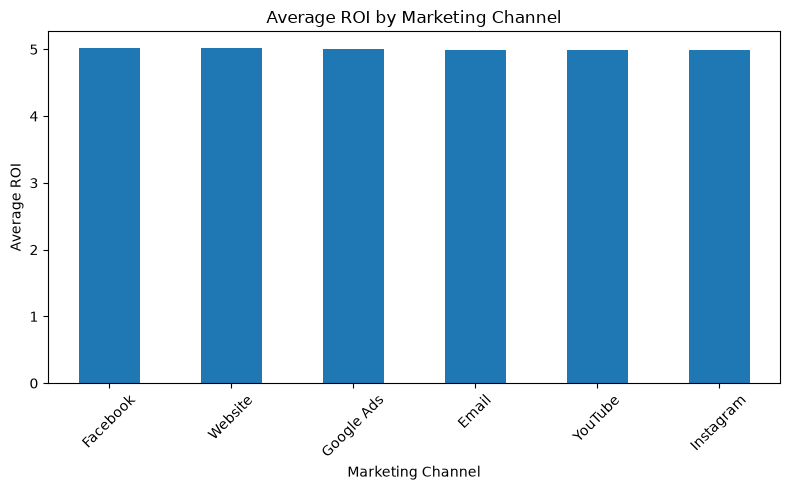

In [34]:
import matplotlib.pyplot as plt

roi_channel = df.groupby("Channel_Used")["ROI"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
roi_channel.plot(kind="bar")

plt.title("Average ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

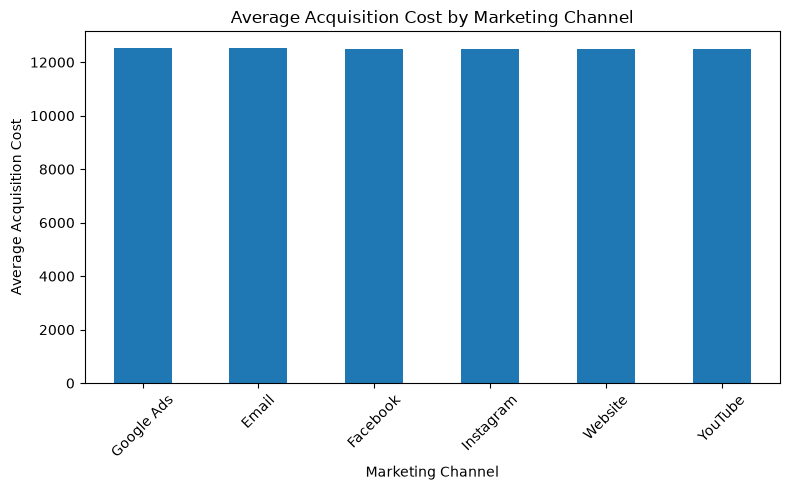

In [35]:
acquisition_channel = df.groupby("Channel_Used")["Acquisition_Cost"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
acquisition_channel.plot(kind="bar")

plt.title("Average Acquisition Cost by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average Acquisition Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

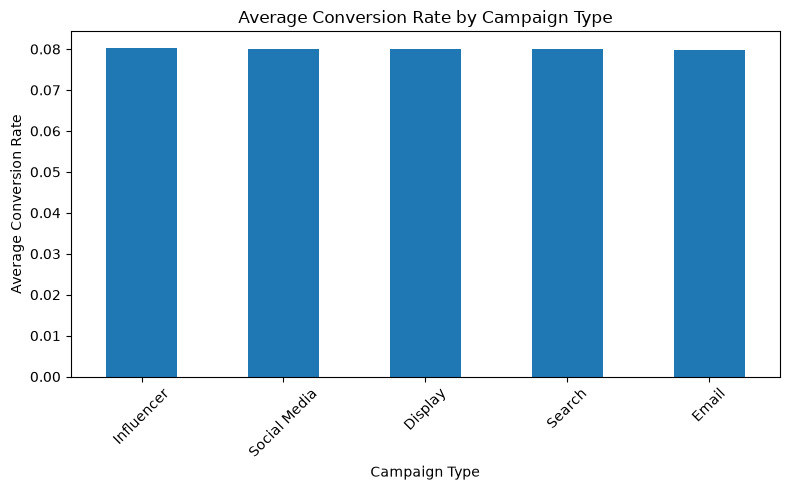

In [36]:
conversion_campaign = df.groupby("Campaign_Type")["Conversion_Rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
conversion_campaign.plot(kind="bar")

plt.title("Average Conversion Rate by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Average Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


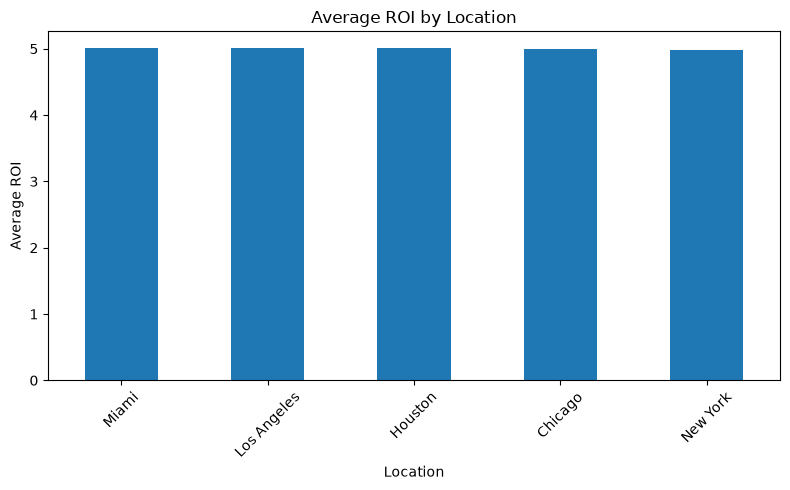

In [37]:
roi_location = df.groupby("Location")["ROI"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
roi_location.plot(kind="bar")

plt.title("Average ROI by Location")
plt.xlabel("Location")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

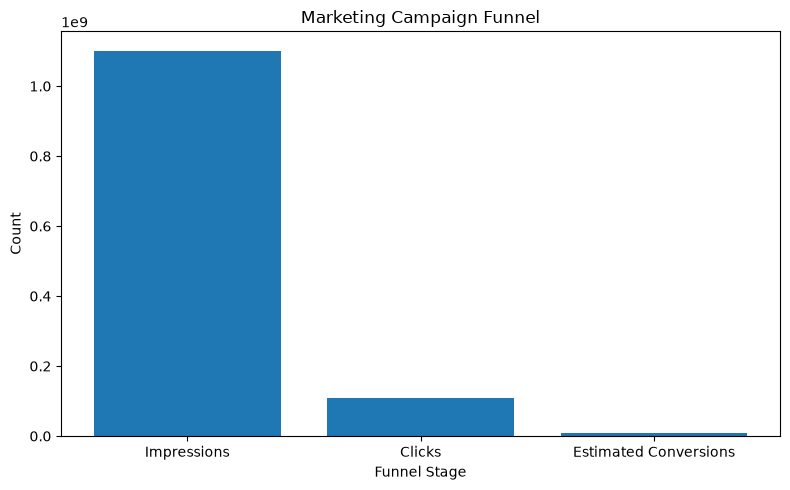

In [38]:
funnel_data = {
    "Stage": ["Impressions", "Clicks", "Estimated Conversions"],
    "Count": [total_impressions, total_clicks, round(total_conversions)]
}

funnel_df = pd.DataFrame(funnel_data)

plt.figure(figsize=(8, 5))
plt.bar(funnel_df["Stage"], funnel_df["Count"])

plt.title("Marketing Campaign Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

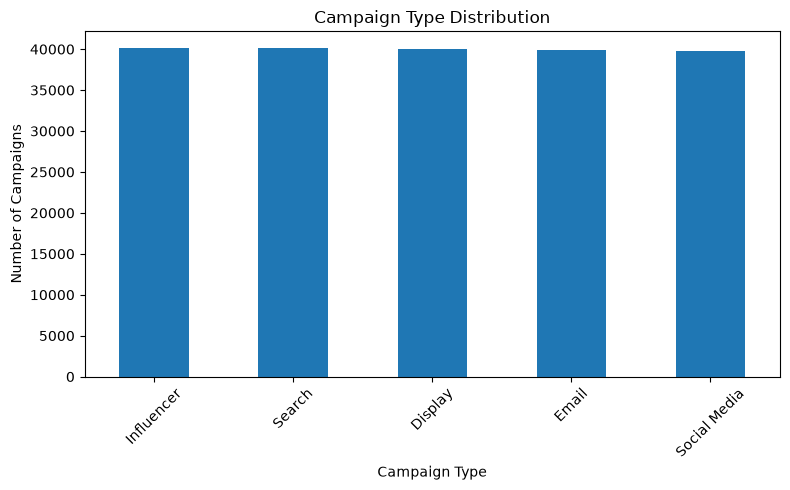

In [39]:
campaign_counts = df["Campaign_Type"].value_counts()

plt.figure(figsize=(8, 5))
campaign_counts.plot(kind="bar")

plt.title("Campaign Type Distribution")
plt.xlabel("Campaign Type")
plt.ylabel("Number of Campaigns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()